# Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Загрузим данные (EDA)

ссылка на датасет:
https://www.kaggle.com/competitions/chocolate-rating-prediction-ai-edu/data

### Часть 1.
Пробежимся по данным, уберем основные проблемы (пропуски, дубликаты)

In [6]:
df = pd.read_csv('chocolate_train.csv')
print(df.shape)
df.head()

(1255, 9)


,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


   **Описание данных** \
`Company` - компания производитель \
`Specific Bean Origin` - географический регион происхождения \
`REF` - параметр, определяющий момент внесения записи в базу данных (чем выше значение, тем "свежее" запись)\
`Review`- дата публикации отзыва\
`Cocoa Percent` - процентное содержание какао\
`Company Location` - страна производитель\
`Rating` - экспертный рейтинг\
`Bean Type` - используемый сорт какао-бобов, если таковой имеется\
`Broad Bean Origin` - географический регион происхождения какао-бобов

Данных немного, однако очень много категориальных колонок. Попробуем что то с ними придумать позже

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1255 non-null   object 
 1   Specific Bean Origin  1255 non-null   object 
 2   REF                   1255 non-null   int64  
 3   Review                1255 non-null   int64  
 4   Cocoa Percent         1255 non-null   object 
 5   Company Location      1255 non-null   object 
 6   Rating                1255 non-null   float64
 7   Bean Type             1254 non-null   object 
 8   Broad Bean Origin     1254 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 88.4+ KB


Кажется, пропусков практически нет.. Или?

In [11]:
display(df.describe())
display(df.describe(include='object'))

,REF,Review,Rating
count,1255.000000,1255.000000,1255.000000
mean,1045.152191,2012.382470,3.176494
std,551.284249,2.922499,0.478948
min,5.000000,2006.000000,1.000000
25%,593.000000,2010.000000,2.750000
50%,1077.000000,2013.000000,3.250000
75%,1514.000000,2015.000000,3.500000
max,1952.000000,2017.000000,5.000000


,Company,Specific Bean Origin,Cocoa Percent,Company Location,Bean Type,Broad Bean Origin
count,1255,1255,1255,1255,1254,1254
unique,376,762,40,58,38,84
top,Soma,Madagascar,70%,U.S.A.,,Venezuela
freq,35,39,461,521,628,144


In [12]:
print(df['Bean Type'].unique()) # это позволяет нам узнать, как на самом деле они закодированы

['Trinitario' '\xa0' 'Criollo' 'Criollo, Trinitario' 'Forastero (Arriba)'
 'Amazon mix' 'Forastero (Arriba) ASS' 'Forastero' 'Trinitario, Forastero'
 'Forastero (Nacional)' 'Criollo (Porcelana)' 'Criollo (Amarru)'
 'Forastero(Arriba, CCN)' 'Trinitario (Amelonado)' 'Blend'
 'Forastero (Parazinho)' 'Matina' 'Nacional (Arriba)' 'Trinitario, TCGA'
 'Criollo, Forastero' 'Criollo (Ocumare 77)' 'Amazon, ICS' 'Nacional'
 'Criollo (Ocumare)' 'Criollo, +' 'Forastero (Catongo)' 'Amazon'
 'Criollo (Wild)' 'Trinitario, Criollo' 'EET' 'Trinitario (85% Criollo)'
 'Criollo (Ocumare 61)' 'Forastero, Trinitario' 'Blend-Forastero,Criollo'
 'Criollo (Ocumare 67)' 'Forastero (Amelonado)' 'Trinitario, Nacional' nan
 'Forastero (Arriba) ASSS']


Как видим, некоторые пропуски закодированы пустой строкой. Попробуем узнать, много ли таких

In [14]:
column = df.columns
for i in column:
    print(df[df[i] == '\xa0'][i].count())

0
0
0
0
0
0
0
628
55


Достаточно много выходит! Сорт какао-бобов пропущен почти в половине строк данных!

In [16]:
df[df.duplicated()].count()

Company                 0
Specific Bean Origin    0
REF                     0
Review                  0
Cocoa Percent           0
Company Location        0
Rating                  0
Bean Type               0
Broad Bean Origin       0
dtype: int64

Дубликатов нет, уже хорошо!

**Избавимся от NA** \
Пропущенные значения пока оставим как есть (просто будет как отдельная категория). Потом есть идея попробовать закодировать их 2 методами: knn  и просто freq значениями, на улучшении модели

In [19]:
df = df.dropna(axis=0)
df.isna().sum()

Company                 0
Specific Bean Origin    0
REF                     0
Review                  0
Cocoa Percent           0
Company Location        0
Rating                  0
Bean Type               0
Broad Bean Origin       0
dtype: int64

### Часть 2.
Посмотрим на распределение данных, выбросы, коррелограммы и прочее

<Axes: xlabel='Rating', ylabel='Count'>

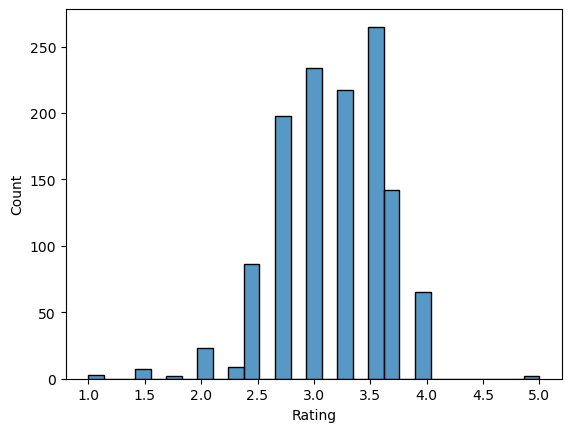

In [21]:
sns.histplot(data=df, x='Rating')

Данные практически нормально распределены, явных выбросов нет

На остальные числовые колонки нет особо смысла смотреть, там все нормально. Интересно посмотреть на общую коррелограмму

In [24]:
# ! pip install association-metrics

In [25]:
import association_metrics as am
df_new = df.apply(lambda x: x.astype('category') if x.dtype == 'object' else x)
cramer = am.CramersV(df_new)
cramer.fit()

,Company,Specific Bean Origin,Cocoa Percent,Company Location,Bean Type,Broad Bean Origin
Company,1.000000,0.771180,0.631741,0.999651,0.616975,0.607303
Specific Bean Origin,0.771180,1.000000,0.773074,0.808513,0.907951,0.983334
Cocoa Percent,0.631741,0.773074,1.000000,0.243831,0.158698,0.266361
Company Location,0.999651,0.808513,0.243831,1.000000,0.291667,0.383039
Bean Type,0.616975,0.907951,0.158698,0.291667,1.000000,0.388294
Broad Bean Origin,0.607303,0.983334,0.266361,0.383039,0.388294,1.000000


In [26]:
df_new.columns

Index(['Company', 'Specific Bean Origin', 'REF', 'Review', 'Cocoa Percent',
       'Company Location', 'Rating', 'Bean Type', 'Broad Bean Origin'],
      dtype='object')

In [27]:
df_new_drop = df_new[['Company', 'Specific Bean Origin', 'REF', 'Review', 'Cocoa Percent',
        'Rating', 'Bean Type']]

In [28]:
cramer_new = am.CramersV(df_new_drop)
cramer_new.fit()

,Company,Specific Bean Origin,Cocoa Percent,Bean Type
Company,1.000000,0.771180,0.631741,0.616975
Specific Bean Origin,0.771180,1.000000,0.773074,0.907951
Cocoa Percent,0.631741,0.773074,1.000000,0.158698
Bean Type,0.616975,0.907951,0.158698,1.000000


А вот тут уже намного интереснее! Мы получили почти 1 корреляцию в некоторых колонках, что достаточно логично. Попробуем их удалить пока, чтобы не было **совершенной мультиколлинеарности**

# Baseline

In [31]:
cat_feature = ['Company', 'Specific Bean Origin', 'Cocoa Percent', 'Bean Type']
y = df_new_drop['Rating']
X = df_new_drop.drop('Rating', axis=1)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

In [33]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

In [34]:
cat_boost = CatBoostRegressor(cat_features=cat_feature, verbose=0).fit(X_train, y_train)
pred_cat = cat_boost.predict(X_test)

In [35]:
print(r2_score(y_test, pred_cat))

0.21243358223205966


## А теперь просто cat boost по первоначальным данным

In [37]:
cat_feature_null = np.array(df.select_dtypes(include='object').columns)
y = df['Rating']
X = df.drop(['Rating'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

cat_boost = CatBoostRegressor(cat_features=cat_feature_null, verbose=0).fit(X_train, y_train)
pred_cat = cat_boost.predict(X_test)
print(r2_score(y_test, pred_cat))

0.2199695364718548


**На самом деле,** после нескольких запусков, понимаем, что очень случайные метрики (в среднем от 0.07 до 0.22)